 # Final Simple Project: Complete ML Classification Pipeline

## Objective
Build a complete **Machine Learning classification pipeline** from data generation to visualization using Python, NumPy, and Matplotlib.

---

## Pipeline Steps

### 1. Generate Synthetic Data
- Create a **2D dataset** with two classes.
- Each sample has **2 features (X1, X2)**.
- Create corresponding class labels (`0` and `1`).

---

### 2. Normalize the Features
Apply **Z-Score Normalization** to standardize the features.
$$
Z = \frac{X - \mu}{\sigma}
$$

Purpose:
- Center data around **0**.
- Scale features to have **standard deviation = 1**.
- Improve model training.

---

### 3. Create a Simple Model Class
Implement a model using OOP.

The class should include:
- `__init__()` → Initialize model parameters.
- `predict()` → Predict class labels.
- `calculate_error()` → Compute classification error.

---

### 4. Make Predictions
Use the model to predict the class for each sample.

Compare:
- True labels
- Predicted labels

---

### 5. Calculate Error
Evaluate the model performance.

Example metrics:
- Accuracy
- Classification Error

---

### 6. Visualize the Results (2×2 Subplots)

Create a figure with four plots:

1. **Original Dataset**
   - Scatter plot of the two classes.

2. **Normalized Dataset**
   - Scatter plot after Z-score normalization.

3. **Model Predictions**
   - Scatter plot colored by predicted classes.

4. **Prediction Results**
   - Highlight correct and incorrect predictions or display the decision results.

---

## Concepts Covered

- Synthetic Data Generation
- NumPy Arrays
- Z-Score Normalization
- Object-Oriented Programming (OOP)
- Prediction
- Error Calculation
- Scatter Plots
- Matplotlib `subplots()`
- Machine Learning Pipeline

---

## Goal

Combine everything you've learned into one complete mini Machine Learning project:
- Generate Data
- Preprocess Data
- Build a Model
- Predict
- Evaluate
- Visualize


Accuracy: 0.87
Error: 0.13


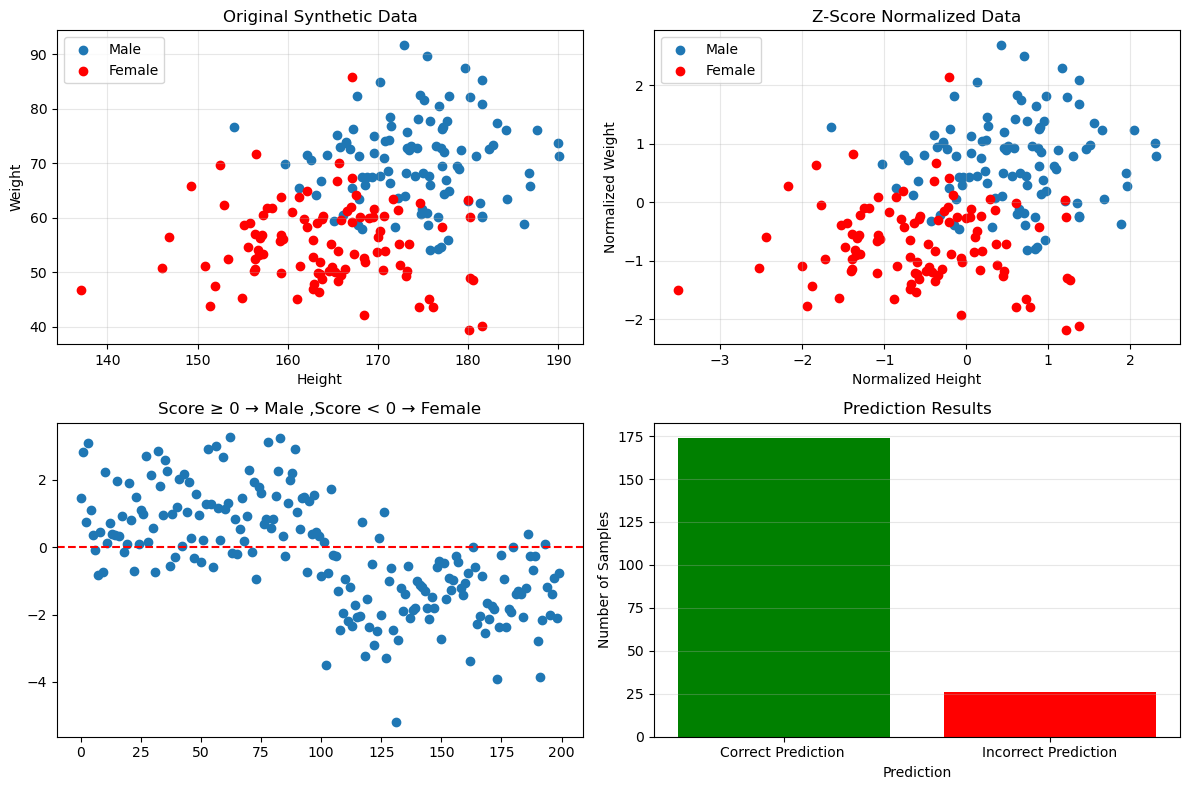

In [55]:
# Given a person's height and weight, this project predicts whether the person is male (1) or female (0).
# It generates synthetic data, normalizes the features, builds a simple classification model,
# and evaluates its performance using prediction accuracy and classification error.

import numpy as np
import matplotlib.pyplot as plt


# 1. Generate Synthetic Data

np.random.seed(42)
# Male: Height, Weight
# loc -> mean , scale-> std , size(num of rows , num of colums )
male = np.random.normal(
    loc=[175, 70],
    scale=[8, 8],
    size=(100, 2)
)

# Female: Height, Weight
female = np.random.normal(
    loc=[163, 55],
    scale=[8, 8],
    size=(100, 2)
)

# All Features
X = np.vstack((male, female))

# Labels
# Male = 1, Female = 0
y = np.array([1] * 100 + [0] * 100)


# 2. Z-Score Normalization

mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X_norm = (X - mean) / std


# 3. Simple Model Class

class SimpleModel:

    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def predict(self, X):
        scores = X @ self.weights + self.bias
        return (scores >= 0).astype(int)

    def error(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions != y)



# 4. Create Model

weights = np.array([1.0, 1.0])
bias = -0.2

model = SimpleModel(weights, bias)


# 5. Predictions & Error

predictions = model.predict(X_norm)

error = model.error(X_norm, y)
accuracy = 1 - error

print("Accuracy:", accuracy)
print("Error:", error)


fig,axes = plt.subplots(2,2,figsize=(12,8))

axes[0,0].scatter(male[ : ,0],male[ : ,1],label="Male")
axes[0,0].scatter(female[ : ,0],female[ : ,1],c='r',label="Female")
axes[0,0].set_title("Original Synthetic Data")
axes[0,0].set_xlabel("Height")
axes[0,0].set_ylabel("Weight")
axes[0,0].grid(True,alpha=0.3)
axes[0,0].legend()

axes[0,1].scatter(X_norm[ :100 , 0],X_norm[ : 100, 1],label="Male")
axes[0,1].scatter(X_norm[ 100: , 0],X_norm[ 100: , 1],c='r',label="Female")
axes[0,1].set_title("Z-Score Normalized Data")
axes[0,1].set_xlabel("Normalized Height")
axes[0,1].set_ylabel("Normalized Weight")
axes[0,1].grid(True,alpha=0.3)
axes[0,1].legend()


axes[1,0].scatter(range(200),X_norm@weights+bias)
axes[1,0].axhline(0, color="red", ls="--")
axes[1,0].set_title("Score ≥ 0 → Male ,Score < 0 → Female")

correct = np.sum(predictions == y)
wrong = np.sum(predictions != y)
axes[1,1].bar(["Correct Prediction ","Incorrect Prediction"],[correct,wrong],color=["green","red"])
axes[1, 1].set_title("Prediction Results")
axes[1, 1].set_xlabel("Prediction")
axes[1, 1].set_ylabel("Number of Samples")
axes[1, 1].grid(axis="y", alpha=0.3)

plt.tight_layout()